# Introduction to Logistic Regression

Logistic Regression in supervised learning algorithm for binary classification. Logistic Regression is suitable model for problems which has a binary output. It is a special case of linear regression where the target variable is categorical in nature. It is a linear model that uses a sigmoid function to map the output to a probability between 0 and 1.

<div style="text-align:center"><img src="https://miro.medium.com/v2/resize:fit:640/format:webp/1*klFuUpBGVAjTfpTak2HhUA.png" /></div>

# Importing the required libraries

In [18]:
import torch
import torch.nn as nn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification

# Creating the dataset for binary classification

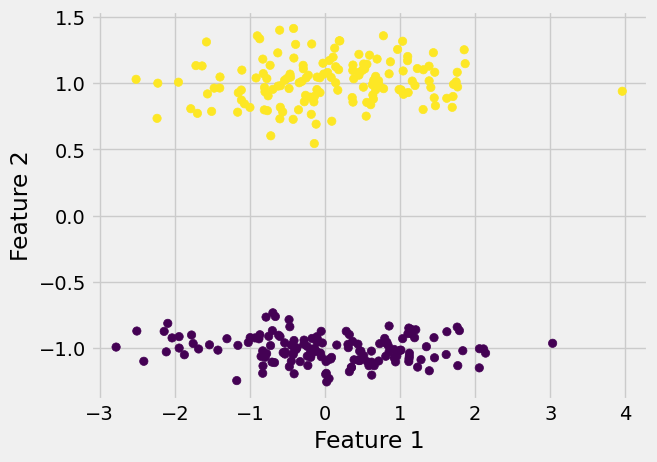

In [19]:
features, targets = make_classification(    
                                        n_samples = 300,
                                        n_features = 2,
                                        n_informative = 1,
                                        n_redundant = 0,
                                        n_clusters_per_class = 1,
                                        random_state = 1
                                        )


plt.style.use('fivethirtyeight')
plt.scatter(features[:,0], features[:,1], c=targets)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


# Prepare the data for training

In [20]:
inputs = torch.from_numpy(features).float()
targets = torch.from_numpy(targets).float().unsqueeze(1)

# Split the dataset into train and test
train_inputs = inputs[:200]
train_targets = targets[:200]
test_inputs = inputs[200:]
test_targets = targets[200:]

# Define the Logistic Regression model

In [21]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super(LogisticRegression, self).__init__()
        
        # Define the linear layer with 2 input features and 1 output feature
        self.linear = nn.Linear(2, 1)
        # Define the sigmoid activation function
        self.sigmoid = nn.Sigmoid()
    
    # Define the forward pass of the model
    def forward(self, x):
        out = self.linear(x) # Pass the input through the linear layer
        out = self.sigmoid(out) # Apply the sigmoid activation function
        return out
    
model = LogisticRegression()


# Define the loss function and optimizer:

In [22]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train the model

In [27]:
# Iterate over epochs
for epoch in range(10000):
    # Zero the gradients
    optimizer.zero_grad()
    # Forward pass
    outputs = model(train_inputs)
    # Calculate loss
    loss = criterion(outputs, train_targets)
    # Backward pass
    loss.backward()
    # Update parameters
    optimizer.step()

    if (epoch+1) % 100 == 0:
        # 1. Тренировочный loss (уже есть)
        train_loss = loss.item()

        # 2. Тестовый loss (вычисляем без градиентов)
        with torch.no_grad():
            test_outputs = model(test_inputs)            # предсказания на тесте
            test_loss = criterion(test_outputs, test_targets).item()  # значение лосса

        print(f'Epoch: {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch: 100, Train Loss: 0.0064, Test Loss: 0.0076
Epoch: 200, Train Loss: 0.0058, Test Loss: 0.0070
Epoch: 300, Train Loss: 0.0054, Test Loss: 0.0065
Epoch: 400, Train Loss: 0.0050, Test Loss: 0.0060
Epoch: 500, Train Loss: 0.0046, Test Loss: 0.0056
Epoch: 600, Train Loss: 0.0042, Test Loss: 0.0052
Epoch: 700, Train Loss: 0.0039, Test Loss: 0.0049
Epoch: 800, Train Loss: 0.0037, Test Loss: 0.0045
Epoch: 900, Train Loss: 0.0034, Test Loss: 0.0042
Epoch: 1000, Train Loss: 0.0032, Test Loss: 0.0040
Epoch: 1100, Train Loss: 0.0030, Test Loss: 0.0037
Epoch: 1200, Train Loss: 0.0028, Test Loss: 0.0035
Epoch: 1300, Train Loss: 0.0026, Test Loss: 0.0033
Epoch: 1400, Train Loss: 0.0024, Test Loss: 0.0031
Epoch: 1500, Train Loss: 0.0023, Test Loss: 0.0029
Epoch: 1600, Train Loss: 0.0021, Test Loss: 0.0027
Epoch: 1700, Train Loss: 0.0020, Test Loss: 0.0026
Epoch: 1800, Train Loss: 0.0019, Test Loss: 0.0024
Epoch: 1900, Train Loss: 0.0018, Test Loss: 0.0023
Epoch: 2000, Train Loss: 0.0017, Test Lo

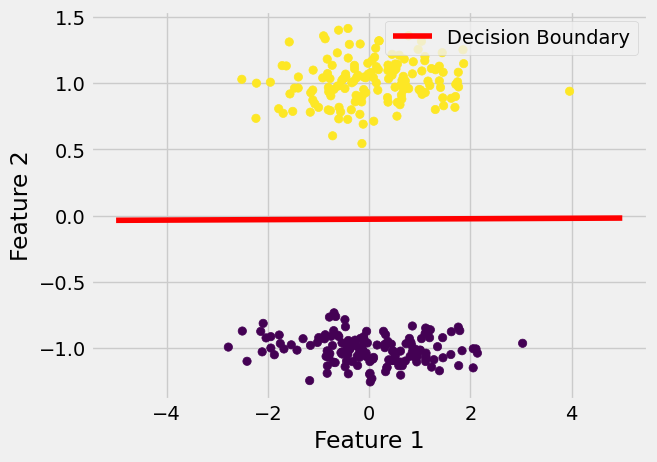

In [28]:
# Get the weights and bias of the trained model
w = model.linear.weight.detach().numpy()
b = model.linear.bias.item()

# Plot the decision boundary line
x1 = np.array([-5, 5])
x2 = -(w[0,0]*x1 + b)/w[0,1]
plt.plot(x1, x2, 'r', label='Decision Boundary')
plt.scatter(features[:,0], features[:,1], c=targets)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.show()

# Predicting on test data

In [25]:
with torch.no_grad():
    # Forward pass on the test set
    outputs = model(test_inputs)

    # Convert the outputs to binary predictions
    predictions = (outputs >= 0.5).float()

    # Compute the accuracy
    accuracy = ((predictions == test_targets).sum() / test_targets.shape[0]).item()

    # Print the accuracy
    print('Test Accuracy: {:.4f}'.format(accuracy))

Test Accuracy: 1.0000
